[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MatsubaraSoda/Notebook/blob/main/notebooks/%E7%89%A9%E7%90%86%E5%AD%A6/%E7%94%B5%E7%A3%81%E5%AD%A6/%E5%85%89%E5%AD%A6/hyperbola-surface.ipynb)

# 双曲线表面透镜

这是学习 Hetch 《光学》的笔记，`5.2.1 Aspherical Surfaces` 的内容。讲述如何使得从点光源射出的”发散光“，重塑为”平行光“。

这只需要一个表面为双曲线形状的透镜即可做到，不过对位置有一定的要求。通常的做法是将点光源放置在双曲线的左焦点 $F_1(-c, 0)$上；透镜的顶点对应双曲线右分支的 $(a, 0)$ 半长轴位置。同时约定空气的折射率为 $n_i = 1$，透镜的折射率为 $n_t = e = \frac{c}{a}$ （即与双曲线的离心率相等）。

给出双曲线的标准形式：

$$
\left\{ (x,y) \in \mathbb{R}^2 \mid \frac{x^2}{a^2} - \frac{y^2}{b^2} = 1 \right\}
$$

让我们先绘制左焦点与右分支：

## Step 1: 绘制左焦点与右分支

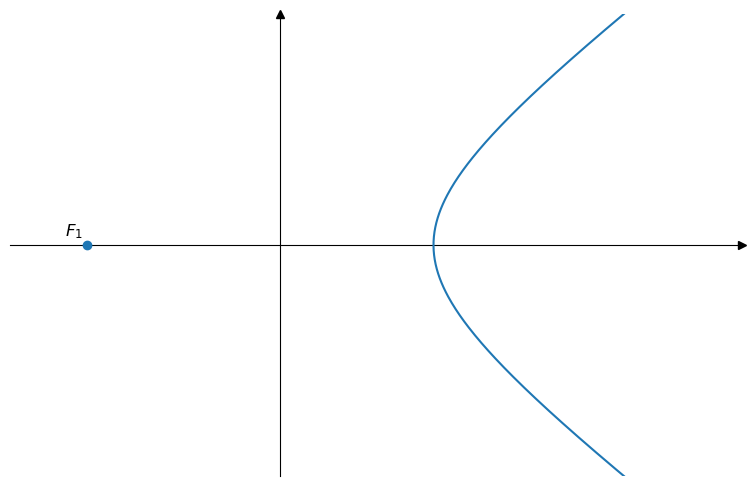

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 全局约定数值
a, b, c = 4.0, 3.0, 5.0                     # 双曲线参数
e = c / a                                   # 离心率
n_i, n_t = 1.0, e                           # 折射率，空气与透镜
source = np.array([-c, 0])                  # 左焦点，点光源
angles_deg = np.linspace(-30, 30, 15)       # 点光源发散角度 (deg)
angles_rad = np.deg2rad(angles_deg)         # 点光源发散角度 (rad)
incident_rays = np.empty((0, 2))            # 入射光线
intersection_points = np.empty((0, 2))      # 交点坐标
normals = np.empty((0, 2))                  # 交点位置的双曲线法向量（归一化）
refraction_rays_unit = np.empty((0, 2))     # 折射光线

def set_scene():
    
    ax.spines['left'].set_position('zero')
    ax.spines['bottom'].set_position('zero')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim([-7,12])
    ax.set_ylim([-6, 6])

    ax.plot(1, 0, ">k", transform=ax.get_yaxis_transform(), clip_on=False)
    ax.plot(0, 1, "^k", transform=ax.get_xaxis_transform(), clip_on=False)

def draw_right_hyperbola():

    y_vals = np.linspace(-10, 10, 500)
    x_vals = np.sqrt(a**2 / b**2 * y_vals**2 + a**2)
    
    ax.plot(x_vals, y_vals, zorder=5)

def draw_left_focus():

    ax.scatter(-c, 0, zorder=5)
    ax.text(-c-0.1, 0.1, r'$F_1$', ha='right', va='bottom', fontsize=12)

fig, ax = plt.subplots(figsize=(10, 6))
set_scene()
draw_right_hyperbola()
draw_left_focus()

## Step 2: 绘制入射光线

接下来，我们从左焦点 $F_1$ 发射若干光线，它们将与透镜表面相交，由此得到入射光线 `incident_rays`。

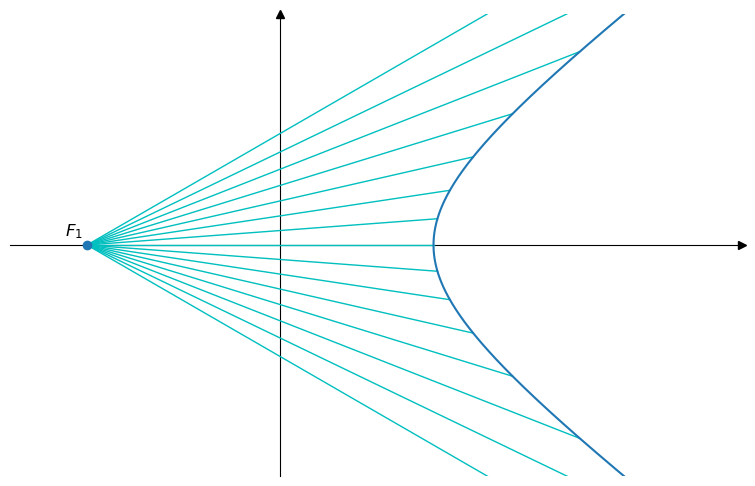

In [2]:
def _find_intersection_point(angles_rad):
    """
    入射光线的参数方程为 source + t * direction

    双曲线标准方程为 x**2 / a**2 - y**2 / b**2 - 1
    """
    import sympy as sp

    t = sp.symbols('t', positive=True)
    x, y = sp.symbols('x y', real=True)
    source_sp = sp.Matrix(source)
    direction = sp.Matrix([np.cos(angles_rad), np.sin(angles_rad)])

    eq_hyperbola = x**2 / a**2 - y**2 / b**2 - 1
    eq_incident_ray = source_sp + t * direction

    solutions = sp.solve(eq_hyperbola.subs({x: eq_incident_ray[0], y: eq_incident_ray[1]}), t)
    if len(solutions) != 2:         # 至少要有两个解，才意味着与右分支有交点
        return None                 # 使用 None 表示没有找到期望解

    t_val = max(solutions)          # 选择右分支
    intersection_point = source_sp + t_val * direction

    return np.array(intersection_point, dtype=float).flatten()

def _find_intersection_points():
    valid_points = []
    for angle_rad in angles_rad:
        point = _find_intersection_point(angle_rad)
        if point is not None:
            valid_points.append(point)
    
    return np.array(valid_points, dtype=float)

intersection_points = _find_intersection_points()
# display(intersection_points)

def _find_incident_rays():
    return np.array(intersection_points - source, dtype=float)

incident_rays = _find_incident_rays()
# display(incident_rays)

def draw_incident_rays():    
    start = source
    for incident_ray in incident_rays:
        end = start + incident_ray
        ax.plot([start[0], end[0]], [start[1], end[1]], color='c', linewidth=1, zorder=4)

fig, ax = plt.subplots(figsize=(10, 6))
set_scene()
draw_right_hyperbola()
draw_left_focus()
# 绘制入射光
draw_incident_rays()

## Step 3: 绘制折射光线

我们在交点处应用斯涅尔定律（折射定律），计算出折射光线并绘制。

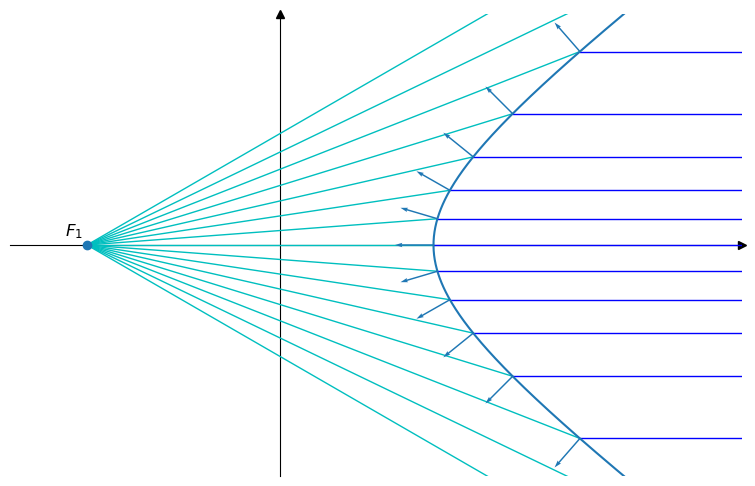

In [3]:
def _find_normals():
    import sympy as sp

    x, y = sp.symbols('x y', real=True)
    eq_hyperbola = x**2 / a**2 - y**2 / b**2 - 1
    gradient = [eq_hyperbola.diff(x), eq_hyperbola.diff(y)]

    normals = []
    for intersection_point, incident_ray in zip(intersection_points, incident_rays):        
        normal = [
            float(gradient[0].subs({x: intersection_point[0]})),
            float(gradient[1].subs({y: intersection_point[1]}))
        ]
        normal = normal / np.linalg.norm(normal)

        if np.dot(normal, incident_ray) > 0:    # 二者同向
            normal = -normal                    # 则法向量取反

        normals.append(normal)

    return np.array(normals, dtype=float)

normals = _find_normals()
# display(normals)

def draw_normals():
    for intersection_point, normal in zip(intersection_points, normals):
        ax.quiver(intersection_point[0], intersection_point[1], normal[0], normal[1],
          angles='xy', scale_units='xy', scale=1,
          color='C0', width=0.002, zorder=4)

def _find_t_from_i_and_n(i, n):
    eta = n_i / n_t
    cos_theta_i = - np.dot(i, n)
    cos_theta_t = np.sqrt(1 - eta**2 * (1 - cos_theta_i**2))

    return eta * i + (eta * cos_theta_i - cos_theta_t) * n

def _find_refraction_rays_unit():
    incident_rays_unit = incident_rays / np.linalg.norm(incident_rays, axis=1, keepdims=True)

    t = []
    for incident_ray_unit, normal in zip(incident_rays_unit, normals):
        refraction_ray_unit = _find_t_from_i_and_n(incident_ray_unit, normal)
        t.append(refraction_ray_unit)

    return np.array(t, dtype=float)

refraction_rays_unit = _find_refraction_rays_unit()
# display(refraction_rays_unit)

def draw_refraction_rays():
    refraction_ray_len = max(ax.get_xlim()[1] - ax.get_xlim()[0], 
                             ax.get_ylim()[1] - ax.get_ylim()[0])
    for intersection_point, refraction_ray_unit in zip(intersection_points, refraction_rays_unit):
        end = intersection_point + refraction_ray_unit * refraction_ray_len
        ax.plot([intersection_point[0], end[0]], [intersection_point[1], end[1]], 'b-', lw=1, zorder=4)

fig, ax = plt.subplots(figsize=(10, 6))
set_scene()
draw_right_hyperbola()
draw_left_focus()
draw_incident_rays()
draw_normals()
draw_refraction_rays()

## 总结

通过上述的数值计算与可视化模拟，我们直观地验证了 Hecht《光学》中关于双曲线非球面透镜（Aspherical Surfaces）的结论：

1. **完美准直特性**：当点光源放置在双曲线的左焦点 $F_1(-c, 0)$，且透镜表面的形状为双曲线的右分支、透镜材料的折射率正好等于双曲线的离心率（$n_t = e = \frac{c}{a}$，假设空气 $n_i=1$）时，所有从焦点发出的发散光线经过折射后，都会变成**完全平行于主光轴（x 轴）的平行光**。
2. **计算与推导的实践**：在代码实现中，我们完整走通了光线追踪（Ray Tracing）的核心流程：
   - 联立射线参数方程与双曲线标准方程，通过解析法求出**光线交点**。
   - 利用偏导数求出曲面在交点处的**法向量**。
   - 运用**斯涅尔定律的向量形式**（$\mathbf{t} = \eta \mathbf{i} + (\eta \cos\theta_i - \cos\theta_t) \mathbf{n}$），直接计算出折射光线的方向。

这为后续更复杂的光学元件（如椭圆表面透镜、抛物面反射镜等）的仿真奠定了很好的代码与数学基础。